# 03 · Preprocessing, feature engineering and feature selection
The exact `Pipeline` used in training **and** by the API (`app/ml/preprocessing.py`).

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
BACKEND = (Path.cwd().parent / "backend").resolve()   # notebooks/ -> backend/
sys.path.insert(0, str(BACKEND))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from app.config import settings
pd.set_option("display.width", 140)

In [2]:
from sklearn.model_selection import train_test_split
from app.ml.data import load_dataset
from app.ml.features import CSV_COLUMNS
from app.ml.preprocessing import build_preprocessor, ZeroToNaN, FeatureEngineer
df = load_dataset(settings.DATA_PATH)
X, y = df[CSV_COLUMNS], df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)  # same split as train.py
pre = build_preprocessor(); pre

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('zero_to_nan', ...), ('impute', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,"['Glucose', 'BloodPressure', ...]"
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",True
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False,

## Step by step on three training rows

In [3]:
sample = X_train.head(3)
z = pre.named_steps["zero_to_nan"].fit(X_train).transform(sample); z

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90,62,12,43,27.2,0.580,24
711,5,126,78,27,22,29.6,0.439,40
373,2,105,58,40,94,34.9,0.225,25


In [4]:
pre.fit(X_train)
print("Medians learned from TRAINING rows only:")
dict(zip(CSV_COLUMNS, pre.named_steps["impute"].statistics_.round(2)))

Medians learned from TRAINING rows only:


{'Pregnancies': np.float64(3.0),
 'Glucose': np.float64(117.0),
 'BloodPressure': np.float64(72.0),
 'SkinThickness': np.float64(29.0),
 'Insulin': np.float64(125.0),
 'BMI': np.float64(32.4),
 'DiabetesPedigreeFunction': np.float64(0.38),
 'Age': np.float64(29.0)}

In [5]:
pre.transform(sample).round(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,missingindicator_Glucose,missingindicator_BloodPressure,missingindicator_SkinThickness,missingindicator_Insulin,missingindicator_BMI
353,-0.851,-1.056,-0.827,-1.918,-1.203,-0.770,0.311,-0.792,-0.081,-0.197,-0.631,-0.946,-0.122
711,0.357,0.144,0.478,-0.230,-1.470,-0.418,-0.116,0.561,-0.081,-0.197,-0.631,-0.946,-0.122
373,-0.549,-0.556,-1.153,1.233,-0.555,0.360,-0.765,-0.708,-0.081,-0.197,-0.631,-0.946,-0.122


## Leakage check
If imputation were fitted on all 768 rows, test-set information would leak into training. The pipeline is fitted on `X_train` only; inside cross-validation it is re-fitted on each training fold.

In [6]:
print("Insulin median, train only:", X_train.Insulin.replace(0, np.nan).median())
print("Insulin median, full data :", X.Insulin.replace(0, np.nan).median())
print("Pipeline used             :", pre.named_steps["impute"].statistics_[CSV_COLUMNS.index("Insulin")])

Insulin median, train only: 125.0
Insulin median, full data : 125.0
Pipeline used             : 125.0


## Feature engineering
`FeatureEngineer(enabled=True)` adds `Glucose_x_BMI` and log-transforms the skewed Insulin and DiabetesPedigreeFunction. Whether to use it is a **tuned hyperparameter** (`prep__engineer__enabled`) chosen by cross-validation per model.

In [7]:
pre_eng = build_preprocessor().set_params(engineer__enabled=True).fit(X_train)
list(pre_eng.transform(sample).columns)

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'missingindicator_Glucose',
 'missingindicator_BloodPressure',
 'missingindicator_SkinThickness',
 'missingindicator_Insulin',
 'missingindicator_BMI',
 'Glucose_x_BMI']

In [8]:
cv = json.loads((settings.METRICS_DIR / "cv_results.json").read_text())
pd.DataFrame([{"model": m["display_name"], "engineered features chosen by CV": m["engineered_features"]} for m in cv["models"]])

,model,engineered features chosen by CV
0,Logistic Regression,True
1,Decision Tree,False
2,Random Forest,True
3,Support Vector Machine (RBF),True
4,Gradient Boosting,False
5,K-Nearest Neighbours,True
6,Soft-Voting Ensemble,None


## Feature selection (computed by `train.py` on the training set)

In [9]:
fs = json.loads((settings.METRICS_DIR / "feature_selection.json").read_text())
pd.DataFrame({"ANOVA F": fs["anova_f"], "mutual information": fs["mutual_information"], "RFECV rank": fs["rfecv"]["ranking"]}).sort_values("ANOVA F", ascending=False)

,ANOVA F,mutual information,RFECV rank
Glucose,217.765,0.1334,1
BMI,74.169,0.1056,1
Insulin,39.388,0.0530,1
Age,37.630,0.0838,1
SkinThickness,35.535,0.0000,1
Pregnancies,27.723,0.0297,1
BloodPressure,21.295,0.0000,1
DiabetesPedigreeFunction,17.195,0.0145,1
missingindicator_BloodPressure,1.770,0.0000,1
missingindicator_SkinThickness,1.268,0.0000,1


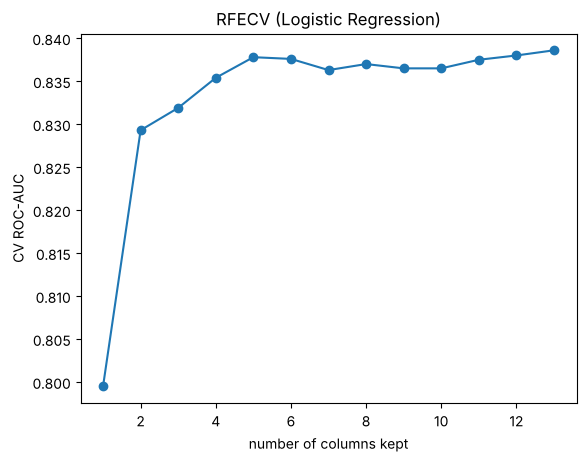

Keep all 8 input features. RFECV's best subset has 13 of 13 columns (CV ROC-AUC 0.8386) vs 0.8386 with all columns, a difference within the 0.005 noise tolerance. With only 8 inputs, dropping features gains nothing measurable and every form field stays used.


In [10]:
plt.plot(range(1, len(fs["rfecv"]["cv_roc_auc_by_n_features"]) + 1), fs["rfecv"]["cv_roc_auc_by_n_features"], marker="o")
plt.xlabel("number of columns kept"); plt.ylabel("CV ROC-AUC"); plt.title("RFECV (Logistic Regression)"); plt.show()
print(fs["decision"])